<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/Project_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 15 - Spotify Songs Cluster

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("song_data.csv")

In [3]:
df.isnull().sum()

,0
song_name,0
song_popularity,0
song_duration_ms,0
acousticness,0
danceability,0
energy,0
instrumentalness,0
key,0
liveness,0
loudness,0


In [4]:
le = LabelEncoder()

In [5]:
df["song_name"] = le.fit_transform(df["song_name"])
df

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,1561,73,262333,0.005520,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,5541,66,216933,0.010300,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,9638,76,231733,0.008170,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,1760,74,216933,0.026400,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,4988,56,223826,0.000954,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18830,6322,60,159645,0.893000,0.500,0.151,0.000065,11,0.1110,-16.107,1,0.0348,113.969,4,0.300
18831,687,60,205666,0.765000,0.495,0.161,0.000001,11,0.1050,-14.078,0,0.0301,94.286,4,0.265
18832,10447,23,182211,0.847000,0.719,0.325,0.000000,0,0.1250,-12.222,1,0.0355,130.534,4,0.286
18833,4131,55,352280,0.945000,0.488,0.326,0.015700,3,0.1190,-12.020,1,0.0328,106.063,4,0.323


In [6]:
df.describe()

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
count,18835.00000,18835.000000,1.883500e+04,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000
mean,6534.86095,52.991877,2.182116e+05,0.258539,0.633348,0.644995,0.078008,5.289196,0.179650,-7.447435,0.628139,0.102099,121.073154,3.959119,0.527967
std,3771.67606,21.905654,5.988754e+04,0.288719,0.156723,0.214101,0.221591,3.614595,0.143984,3.827831,0.483314,0.104378,28.714456,0.298533,0.244632
min,0.00000,0.000000,1.200000e+04,0.000001,0.000000,0.001070,0.000000,0.000000,0.010900,-38.768000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3298.00000,40.000000,1.843395e+05,0.024100,0.533000,0.510000,0.000000,2.000000,0.092900,-9.044000,0.000000,0.037800,98.368000,4.000000,0.335000
50%,6557.00000,56.000000,2.113060e+05,0.132000,0.645000,0.674000,0.000011,5.000000,0.122000,-6.555000,1.000000,0.055500,120.013000,4.000000,0.527000
75%,9792.50000,69.000000,2.428440e+05,0.424000,0.748000,0.815000,0.002570,8.000000,0.221000,-4.908000,1.000000,0.119000,139.931000,4.000000,0.725000
max,13069.00000,100.000000,1.799346e+06,0.996000,0.987000,0.999000,0.997000,11.000000,0.986000,1.585000,1.000000,0.941000,242.318000,5.000000,0.984000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18835 entries, 0 to 18834
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   song_name         18835 non-null  int64  
 1   song_popularity   18835 non-null  int64  
 2   song_duration_ms  18835 non-null  int64  
 3   acousticness      18835 non-null  float64
 4   danceability      18835 non-null  float64
 5   energy            18835 non-null  float64
 6   instrumentalness  18835 non-null  float64
 7   key               18835 non-null  int64  
 8   liveness          18835 non-null  float64
 9   loudness          18835 non-null  float64
 10  audio_mode        18835 non-null  int64  
 11  speechiness       18835 non-null  float64
 12  tempo             18835 non-null  float64
 13  time_signature    18835 non-null  int64  
 14  audio_valence     18835 non-null  float64
dtypes: float64(9), int64(6)
memory usage: 2.2 MB


In [19]:
X = df.iloc[:,1:15]

In [20]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

In [21]:
X_pca

array([[ 4.41214126e+04,  4.49104538e+01],
       [-1.27858776e+03, -1.63018018e+01],
       [ 1.35214123e+04,  1.78017455e+00],
       ...,
       [-3.60005873e+04,  1.08084289e+01],
       [ 1.34068412e+05, -1.60188664e+01],
       [-2.46785878e+04, -2.97552253e+01]])

In [22]:
pca.explained_variance_ratio_.cumsum()[1]

np.float64(0.999999858582658)

In [23]:
from sklearn.cluster import KMeans
distortion =[]
cluster_range = range(1,6)
for i in cluster_range:
  model = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # Added n_init to suppress future warnings
  model.fit(X_pca)
  distortion.append(model.inertia_)

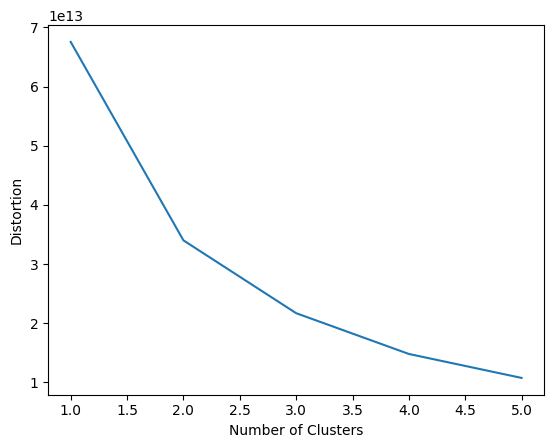

In [24]:
plt.plot(cluster_range,distortion)
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.show()

In [28]:
model = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
model.fit(X_pca)
y = model.predict(X_pca)

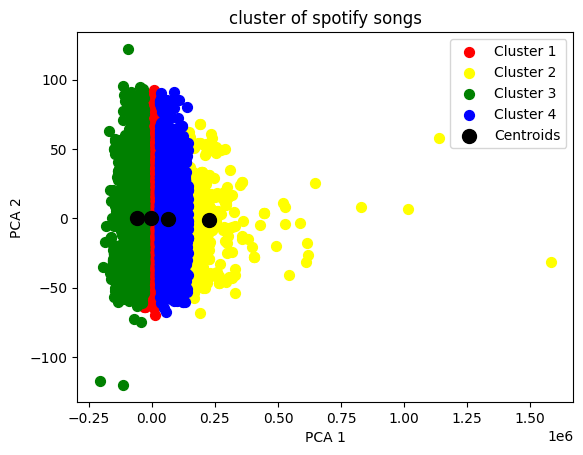

In [29]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red', label='Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='yellow', label='Cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=50,c='green', label='Cluster 3')
plt.scatter(X_pca[y==3,0],X_pca[y==3,1],s=50,c='blue', label='Cluster 4')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='black',label='Centroids')
plt.title('cluster of spotify songs')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')  #0,1,2  clusters #0,1 pca
plt.legend()
plt.show()